#### Installing Dependencies

In [4]:
!pip install comet_ml --quiet
!pip install mitdeeplearning --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.2/786.2 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 54.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 26.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 15.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 107.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.1/278.1 kB 32.0 MB/s eta 0:00:00
   ━━━━━

In [5]:
COMET_API_KEY = "HIr6ya7tkbmZg22EoXJlJrOaB"

#### Imports

In [56]:
import comet_ml
import mitdeeplearning as mdl

import os
import random
import functools
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from pathlib import Path
import tensorflow as tf

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.backends.cudnn as cudnn

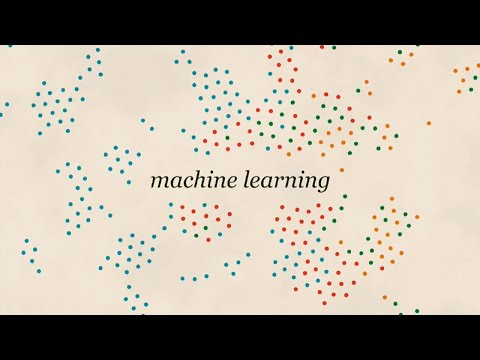

In [57]:
import IPython
IPython.display.YouTubeVideo('59bMh59JQDo')

#### GPU Check

In [29]:
# Check that we are using a GPU, if not switch runtimes
# using Runtime > Change Runtime Type > GPU
if torch.cuda.is_available():
  device = torch.device("cuda")
  cudnn.benchmark = True
  print(device)
else:
  raise ValueError("GPU is not available. Change Colab runtime.")

cuda


In [58]:
assert len(tf.config.list_physical_devices('GPU')) > 0
assert COMET_API_KEY != "", "Please insert your Comet API Key"

#### Loading Training Data

In [64]:
# Get the training data: both images from CelebA and ImageNet
path_to_training_data = tf.keras.utils.get_file('train_face.h5', 'https://www.dropbox.com/s/hlz8atheyozp1yx/train_face.h5?dl=1')
# Instantiate a TrainingDatasetLoader using the downloaded dataset
loader = mdl.lab2.TrainingDatasetLoader(path_to_training_data)


1263889489/1263889489 ━━━━━━━━━━━━━━━━━━━━ 73s 0us/step
Opening /root/.keras/datasets/train_face.h5
Loading data into memory...


#### Examining the Dataset

In [65]:
number_of_training_examples = loader.get_train_size()
(images, labels) = loader.get_batch(100)

B, C, H, W = images.shape

#### Examining the CelebA training dataset

Change the sliders to took at positive and negative training examples! {run: "auto" }

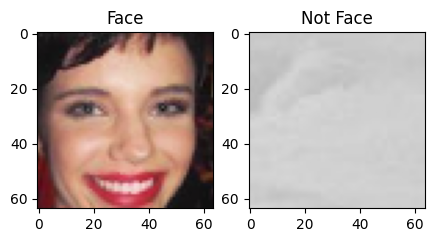

In [67]:
face_images = images[np.where(labels==1)[0]]
not_face_images = images[np.where(labels==0)[0]]

idx_face = 23 #@param {type:"slider", min:0, max:50, step:1}
idx_not_face = 9 #@param {type:"slider", min:0, max:50, step:1}

plt.figure(figsize=(5,5))
plt.subplot(1, 2, 1)
plt.imshow(face_images[idx_face])
plt.title("Face"); plt.grid(False)

plt.subplot(1, 2, 2)
plt.imshow(not_face_images[idx_not_face])
plt.title("Not Face"); plt.grid(False)


#### Define the Standard CNN Model

In [68]:
n_filters = 12  # base number of convolutional filters

'''Function to define a standard CNN model'''
def make_standard_classifier(n_outputs=1):
    Conv2D = functools.partial(tf.keras.layers.Conv2D, padding='same', activation='relu')
    BatchNormalization = tf.keras.layers.BatchNormalization
    Flatten = tf.keras.layers.Flatten
    Dense = functools.partial(tf.keras.layers.Dense, activation='relu')

    model = tf.keras.Sequential([
        Conv2D(filters=1*n_filters, kernel_size=5, strides=2),
        BatchNormalization(),

        Conv2D(filters=2*n_filters, kernel_size=5, strides=2),
        BatchNormalization(),

        Conv2D(filters=4*n_filters, kernel_size=3, strides=2),
        BatchNormalization(),

        Conv2D(filters=6*n_filters, kernel_size=3, strides=2),
        BatchNormalization(),

        Flatten(),
        Dense(512),
        Dense(n_outputs, activation=None),
    ])
    return model

standard_classifier = make_standard_classifier()

#### Training the Standard CNN

In [69]:
### Create a Comet experiment to track our training run ###
def create_experiment(project_name, params):
    # end any prior experiments
    if 'experiment' in locals():
        experiment.end()

    # initiate the comet experiment for tracking
    experiment = comet_ml.Experiment(
                    api_key=COMET_API_KEY,
                    project_name=project_name)
    # log our hyperparameters, defined above, to the experiment
    for param, value in params.items():
        experiment.log_parameter(param, value)
    experiment.flush()

    return experiment

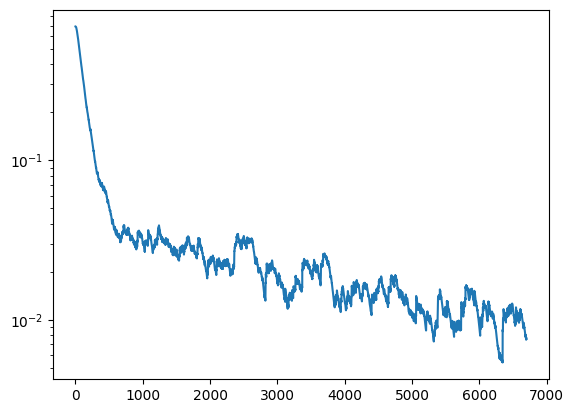

100%|██████████| 3434/3434 [00:59<00:00, 57.40it/s]


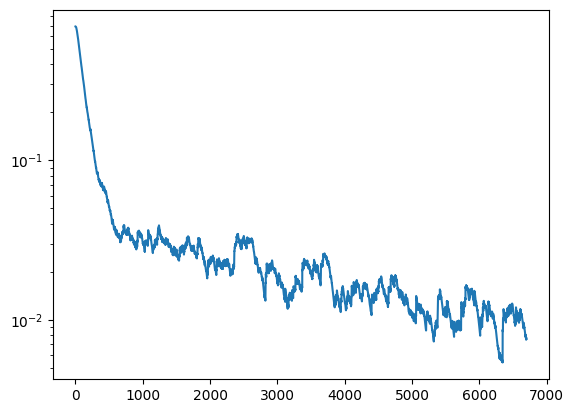

In [70]:
# Training hyperparameters
params = dict(
    batch_size = 32,
    num_epochs = 2,  # keep small to run faster
    learning_rate = 5e-4,
)

experiment = create_experiment("6S191_Lab2_Part2_CNN", params)

optimizer = tf.keras.optimizers.Adam(params["learning_rate"]) # define our optimizer
loss_history = mdl.util.LossHistory(smoothing_factor=0.99) # to record loss evolution
plotter = mdl.util.PeriodicPlotter(sec=2, scale='semilogy')
if hasattr(tqdm, '_instances'): tqdm._instances.clear() # clear if it exists

@tf.function
def standard_train_step(x, y):
    with tf.GradientTape() as tape:
        # feed the images into the model
        logits = standard_classifier(x)
        # Compute the loss
        loss = tf.nn.sigmoid_cross_entropy_with_logits(labels=y, logits=logits)

    # Backpropagation
    grads = tape.gradient(loss, standard_classifier.trainable_variables)
    optimizer.apply_gradients(zip(grads, standard_classifier.trainable_variables))
    return loss

# The training loop!
step = 0
for epoch in range(params["num_epochs"]):
    for idx in tqdm(range(loader.get_train_size()//params["batch_size"])):
        # Grab a batch of training data and propagate through the network
        x, y = loader.get_batch(params["batch_size"])
        loss = standard_train_step(x, y)

        # Record the loss and plot the evolution of the loss as a function of training
        loss_history.append(loss.numpy().mean())
        plotter.plot(loss_history.get())

        experiment.log_metric("loss", loss.numpy().mean(), step=step)
        step += 1

#### Evaluate on a subset of CelebA+Imagenet

In [72]:
(batch_x, batch_y) = loader.get_batch(5000)
y_pred_standard = tf.round(tf.nn.sigmoid(standard_classifier.predict(batch_x)))
acc_standard = tf.reduce_mean(tf.cast(tf.equal(batch_y, y_pred_standard), tf.float32))

print("Standard CNN accuracy on (potentially biased) training set: {:.4f}".format(acc_standard.numpy()))

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Standard CNN accuracy on (potentially biased) training set: 0.9976


#### Load test dataset and plot examples

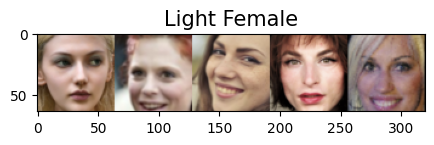

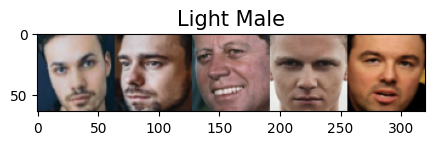

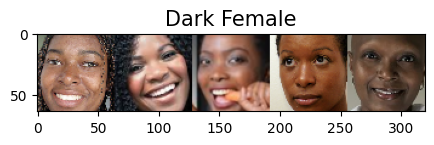

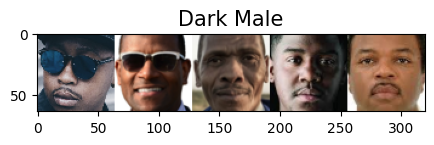

In [73]:
test_faces = mdl.lab2.get_test_faces()
keys = ["Light Female", "Light Male", "Dark Female", "Dark Male"]
for group, key in zip(test_faces, keys):
    plt.figure(figsize=(5, 5))
    plt.imshow(np.hstack(group))
    plt.title(key, fontsize=15)

In [74]:
standard_classifier_logits = [standard_classifier(np.array(x, dtype=np.float32)) for x in test_faces]
standard_classifier_probs = tf.squeeze(tf.sigmoid(standard_classifier_logits))

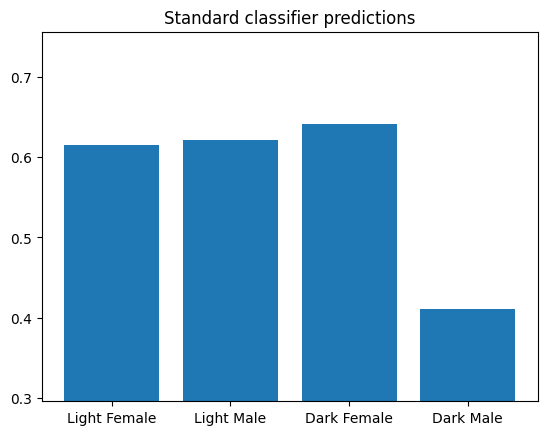

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [76]:
xx = range(len(keys))
yy = standard_classifier_probs.numpy().mean(1)
plt.bar(xx, yy)
plt.xticks(xx, keys)
plt.ylim(max(0,yy.min()-np.ptp(yy)/2.), yy.max()+np.ptp(yy)/2.)
plt.title("Standard classifier predictions");

#### VAE Loss Function

In [77]:
''' Function to calculate VAE loss given:
      an input x,
      reconstructed output x_recon,
      encoded means mu,
      encoded log of standard deviation logsigma,
      weight parameter for the latent loss kl_weight
'''
def vae_loss_function(x, x_recon, mu, logsigma, kl_weight=0.0005):
    latent_loss = 0.5 * tf.reduce_sum(tf.exp(logsigma) + tf.square(mu) - 1 - logsigma, axis=1)
    reconstruction_loss = tf.reduce_mean(tf.abs(x - x_recon), axis=(1, 2, 3))

    vae_loss = kl_weight * latent_loss + reconstruction_loss

    return vae_loss

#### VAE Reparameterization

In [78]:
"""Reparameterization trick by sampling from an isotropic unit Gaussian.
# Arguments
    z_mean, z_logsigma (tensor): mean and log of standard deviation of latent distribution (Q(z|X))
# Returns
    z (tensor): sampled latent vector
"""
def sampling(z_mean, z_logsigma):
    # By default, random.normal is "standard" (ie. mean=0 and std=1.0)
    batch, latent_dim = z_mean.shape
    epsilon = tf.random.normal(shape=(batch, latent_dim))

    z = z_mean + tf.exp(0.5 * z_logsigma) * epsilon

    return z

#### Loss function for DB-VAE

In [79]:
""".
# Arguments
    x: true input x
    x_pred: reconstructed x
    y: true label (face or not face)
    y_logit: predicted labels
    mu: mean of latent distribution (Q(z|X))
    logsigma: log of standard deviation of latent distribution (Q(z|X))
# Returns
    total_loss: DB-VAE total loss
    classification_loss: DB-VAE classification loss
"""
def debiasing_loss_function(x, x_pred, y, y_logit, mu, logsigma):

    vae_loss = vae_loss_function(x, x_pred, mu, logsigma)

    classification_loss = tf.nn.sigmoid_cross_entropy_with_logits(labels=y, logits=y_logit)

    # Use the training data labels to create variable face_indicator:
    #   indicator that reflects which training data are images of faces
    face_indicator = tf.cast(tf.equal(y, 1), tf.float32)

    total_loss = tf.reduce_mean(classification_loss + face_indicator * vae_loss)

    return total_loss, classification_loss

#### DB-VAE Decoder Network

In [80]:
n_filters = 12  # base number of convolutional filters, same as standard CNN
latent_dim = 100  # number of latent variables

def make_face_decoder_network():
    # Functionally define the different layer types we will use
    Conv2DTranspose = functools.partial(tf.keras.layers.Conv2DTranspose, padding='same', activation='relu')
    BatchNormalization = tf.keras.layers.BatchNormalization
    Flatten = tf.keras.layers.Flatten
    Dense = functools.partial(tf.keras.layers.Dense, activation='relu')
    Reshape = tf.keras.layers.Reshape

    # Build the decoder network using the Sequential API
    decoder = tf.keras.Sequential([
        # Transform to pre-convolutional generation
        Dense(units=4*4*6*n_filters),  # 4x4 feature maps (with 6N occurances)
        Reshape(target_shape=(4, 4, 6*n_filters)),

        # Upscaling convolutions (inverse of encoder)
        Conv2DTranspose(filters=4*n_filters, kernel_size=3, strides=2),
        Conv2DTranspose(filters=2*n_filters, kernel_size=3, strides=2),
        Conv2DTranspose(filters=1*n_filters, kernel_size=5, strides=2),
        Conv2DTranspose(filters=3,           kernel_size=5, strides=2),
    ])

    return decoder

#### DB-VAE Class Definition

In [81]:
class DB_VAE(tf.keras.Model):
    def __init__(self, latent_dim):
        super(DB_VAE, self).__init__()
        self.latent_dim = latent_dim

        # Define the number of outputs for the encoder. Recall that we have
        # `latent_dim` latent variables, as well as a supervised output for the
        # classification.
        num_encoder_dims = 2*self.latent_dim + 1

        self.encoder = make_standard_classifier(num_encoder_dims)
        self.decoder = make_face_decoder_network()

    # function to feed images into encoder, encode the latent space, and output
    #   classification probability
    def encode(self, x):
        # encoder output
        encoder_output = self.encoder(x)

        # classification prediction
        y_logit = tf.expand_dims(encoder_output[:, 0], -1)

        # latent variable distribution parameters
        z_mean = encoder_output[:, 1:self.latent_dim+1]
        z_logsigma = encoder_output[:, self.latent_dim+1:]

        return y_logit, z_mean, z_logsigma

    # VAE reparameterization: given a mean and logsigma, sample latent variables
    def reparameterize(self, z_mean, z_logsigma):
        z = sampling(z_mean, z_logsigma)
        return z

    # Decode the latent space and output reconstruction
    def decode(self, z):
        reconstruction = self.decoder(z)
        return reconstruction

    # The call function will be used to pass inputs x through the core VAE
    def call(self, x):
        # Encode input to a prediction and latent space
        y_logit, z_mean, z_logsigma = self.encode(x)

        z = self.reparameterize(z_mean, z_logsigma)
        recon = self.decode(z)
        return y_logit, z_mean, z_logsigma, recon

    # Predict face or not face logit for given input x
    def predict(self, x):
        y_logit, z_mean, z_logsigma = self.encode(x)
        return y_logit

dbvae = DB_VAE(latent_dim)

#### Helper: Get Latent Means

In [82]:
# Function to return the means for an input image batch
def get_latent_mu(images, dbvae, batch_size=1024):
    N = images.shape[0]
    mu = np.zeros((N, latent_dim))
    for start_ind in range(0, N, batch_size):
        end_ind = min(start_ind+batch_size, N+1)
        batch = (images[start_ind:end_ind]).astype(np.float32)/255.
        _, batch_mu, _ = dbvae.encode(batch)
        mu[start_ind:end_ind] = batch_mu
    return mu

#### Resampling Algorithm

In [83]:
### Resampling algorithm for DB-VAE ###

'''Function that recomputes the sampling probabilities for images within a batch
       based on how they distribute across the training data'''
def get_training_sample_probabilities(images, dbvae, bins=10, smoothing_fac=0.001):
    print("Recomputing the sampling probabilities")

    mu = get_latent_mu(images, dbvae)

    # sampling probabilities for the images
    training_sample_p = np.zeros(mu.shape[0])

    # consider the distribution for each latent variable
    for i in range(latent_dim):

        latent_distribution = mu[:,i]
        # generate a histogram of the latent distribution
        hist_density, bin_edges = np.histogram(latent_distribution, density=True, bins=bins)

        # find which latent bin every data sample falls in
        bin_edges[0] = -float('inf')
        bin_edges[-1] = float('inf')

        bin_idx = np.digitize(latent_distribution, bin_edges)

        # smooth the density function
        hist_smoothed_density = hist_density + smoothing_fac
        hist_smoothed_density = hist_smoothed_density / np.sum(hist_smoothed_density)

        # invert the density function
        p = 1.0/(hist_smoothed_density[bin_idx-1])

        p = p / np.sum(p)

        training_sample_p = np.maximum(training_sample_p, p)

    # final normalization
    training_sample_p /= np.sum(training_sample_p)

    return training_sample_p

#### Training the DB-VAE

Starting epoch 1/1
Recomputing the sampling probabilities


100%|██████████| 3434/3434 [00:49<00:00, 69.22it/s]
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : small_cove_2953
COMET INFO:     url                   : https://www.comet.com/ms25941708-perera-h-a-n-s/6s191-lab2-part2-dbvae/6e289a22be0644298930b7cf996e51d9
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     loss [3434] : (0.05563964694738388, 0.9421749711036682)
COMET INFO:   Others:
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#fileId=1tNJGavG79ReWB81XQDpq58LgQcF5296l
COMET INFO:   Parameters:
COMET INFO:     Optimizer                        : adam
COMET INFO:     adam_amsgrad                     : False
COMET INFO:     adam_beta_1                      : 0.9
C

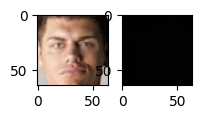

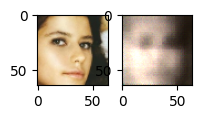

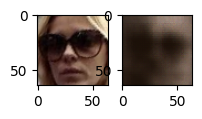

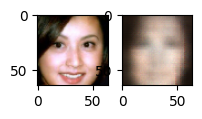

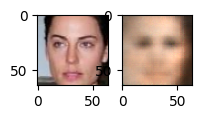

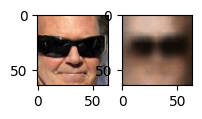

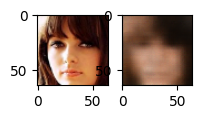

In [84]:
# Hyperparameters
params = dict(
    batch_size = 32,
    learning_rate = 5e-4,
    latent_dim = 100,
    num_epochs = 1,  #DB-VAE needs slightly more epochs to train
)

experiment = create_experiment("6S191_Lab2_Part2_DBVAE", params)

# instantiate a new DB-VAE model and optimizer
dbvae = DB_VAE(params["latent_dim"])
optimizer = tf.keras.optimizers.Adam(params["learning_rate"])

# To define the training operation, we will use tf.function which is a powerful tool
#   that lets us turn a Python function into a TensorFlow computation graph.
@tf.function
def debiasing_train_step(x, y):

    with tf.GradientTape() as tape:
        # Feed input x into dbvae. Note that this is using the DB_VAE call function!
        y_logit, z_mean, z_logsigma, x_recon = dbvae(x)

        loss, class_loss = debiasing_loss_function(x, x_recon, y, y_logit, z_mean, z_logsigma)

    grads = tape.gradient(loss, dbvae.trainable_variables)

    # apply gradients to variables
    optimizer.apply_gradients(zip(grads, dbvae.trainable_variables))
    return loss

# get training faces from data loader
all_faces = loader.get_all_train_faces()

if hasattr(tqdm, '_instances'): tqdm._instances.clear() # clear if it exists

# The training loop -- outer loop iterates over the number of epochs
step = 0
for i in range(params["num_epochs"]):

    IPython.display.clear_output(wait=True)
    print("Starting epoch {}/{}".format(i+1, params["num_epochs"]))

    # Recompute data sampling probabilities
    p_faces = get_training_sample_probabilities(all_faces, dbvae)

    # get a batch of training data and compute the training step
    for j in tqdm(range(loader.get_train_size() // params["batch_size"])):
        # load a batch of data
        (x, y) = loader.get_batch(params["batch_size"], p_pos=p_faces)

        # loss optimization
        loss = debiasing_train_step(x, y)
        experiment.log_metric("loss", loss.numpy().mean(), step=step)

        # plot the progress every 200 steps
        if j % 500 == 0:
            mdl.util.plot_sample(x, y, dbvae)

        step += 1

experiment.end()

#### Evaluate DB-VAE on Test Dataset

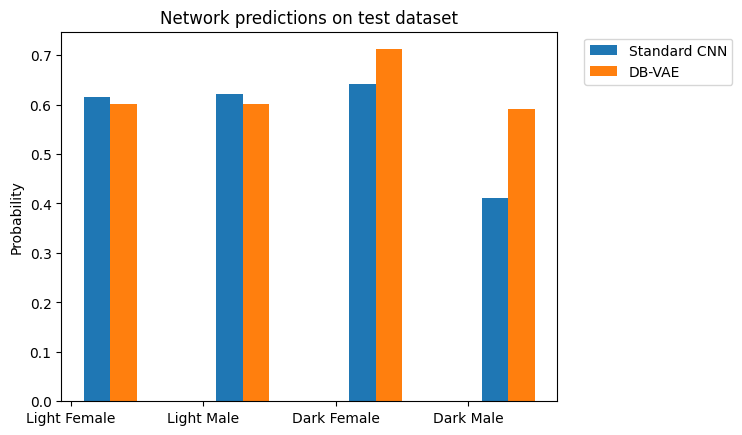

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [85]:
dbvae_logits = [dbvae.predict(np.array(x, dtype=np.float32)) for x in test_faces]
dbvae_probs = tf.squeeze(tf.sigmoid(dbvae_logits))

xx = np.arange(len(keys))
plt.bar(xx+0.2, standard_classifier_probs.numpy().mean(1), width=0.2, label="Standard CNN")
plt.bar(xx+0.4, dbvae_probs.numpy().mean(1), width=0.2, label="DB-VAE")
plt.xticks(xx, keys);
plt.title("Network predictions on test dataset")
plt.ylabel("Probability"); plt.legend(bbox_to_anchor=(1.04,1), loc="upper left");